# Sudan Climate Data Analysis (2015–2026)

This notebook performs data profiling, cleaning, and exploratory data analysis (EDA) on Kenya's climate dataset to identify trends in temperature, rainfall, and other weather variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)

In [2]:
df = pd.read_csv("../data/sudan.csv")
df["Country"] = "Sudan"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


In [3]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


## Date Processing
The YEAR and DOY columns are combined to create a proper datetime column. A Month column is also extracted for seasonal analysis.

In [4]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,2026-03-27,3
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28,3
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29,3
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30,3


## Handling Missing Values
Sentinel values (-999) are replaced with NaN to correctly represent missing data.

In [5]:
df.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset. This indicates that the data collection process did not introduce repeated records, and no rows needed to be removed.

In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


## Summary Statistics Interpretation

The dataset contains 4,108 daily observations spanning from 2015 to 2026, providing a comprehensive view of the study area’s climate over time.

The average temperature (T2M) is approximately 28.76°C, with values ranging from about 13.18°C to 37.99°C. This indicates a generally hot climate with noticeable variability across seasons. The average maximum temperature (T2M_MAX) reaches about 36.77°C, while the minimum temperature (T2M_MIN) drops to around 5.93°C, showing significant daily temperature fluctuations.

Rainfall (PRECTOTCORR) shows strong variability, with a mean of 0.64 mm and a maximum of 66.49 mm. This suggests that precipitation is highly uneven, with many dry days and occasional intense rainfall events, likely linked to seasonal patterns.

Relative humidity (RH2M) averages around 31.36%, ranging from approximately 4.69% to 87.16%, indicating generally dry conditions with intermittent periods of higher moisture.

Wind speed (WS2M) has an average of about 3.48 m/s, suggesting moderate wind conditions with occasional stronger winds reaching up to 9.05 m/s.

Overall, the data indicates a predominantly hot and dry climate, irregular rainfall distribution, and fluctuating humidity levels, which are typical of semi-arid environmental conditions.


In [7]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

### Missing Values Analysis

No missing values were found in the dataset after replacing the sentinel value (-999) with NaN. All columns have 0% missing data, indicating a complete dataset suitable for analysis without additional imputation.

In [8]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()

outliers

np.int64(91)

## Outlier Detection

Outliers were identified using the Z-score method, where values with an absolute Z-score greater than 3 were considered extreme. A total of 91 outlier values were detected across the selected climate variables.

These outliers likely represent extreme weather events such as periods of intense rainfall or unusually high or low temperatures. Since such events are important in climate analysis, the outliers were retained rather than removed in order to preserve meaningful environmental variability.

In [9]:
df = df.ffill()

Since no missing values were present in the dataset, no imputation was required. However, forward-fill was applied as a precautionary step to maintain consistency in the workflow.

In [10]:
df.to_csv("../data/sudan_clean.csv", index=False)

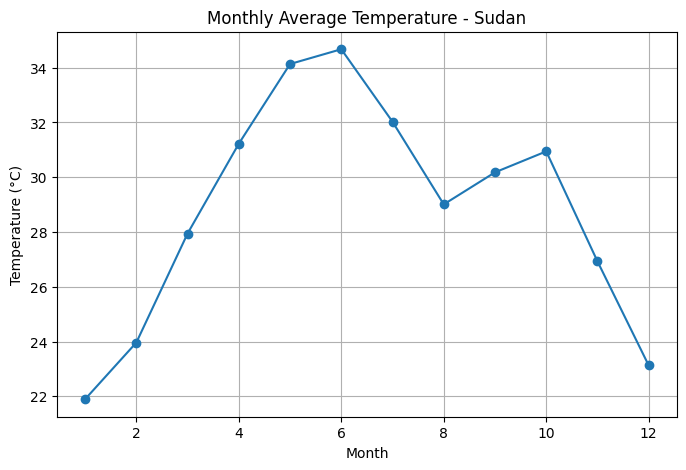

In [12]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(marker='o')
plt.title("Monthly Average Temperature - Sudan")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

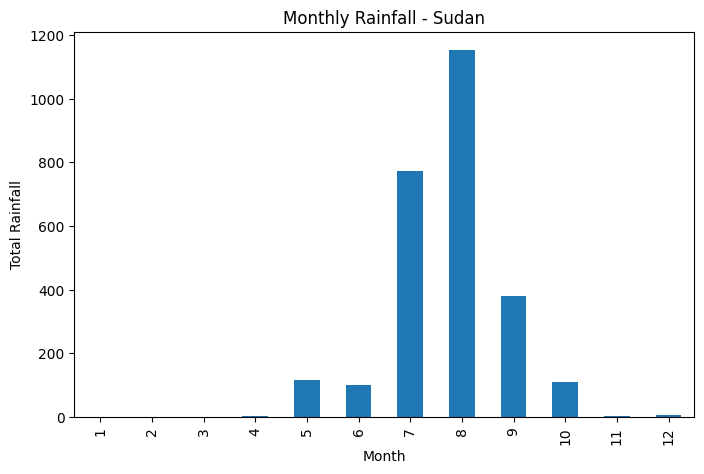

In [13]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall - Sudan")
plt.xlabel("Month")
plt.ylabel("Total Rainfall")
plt.show()

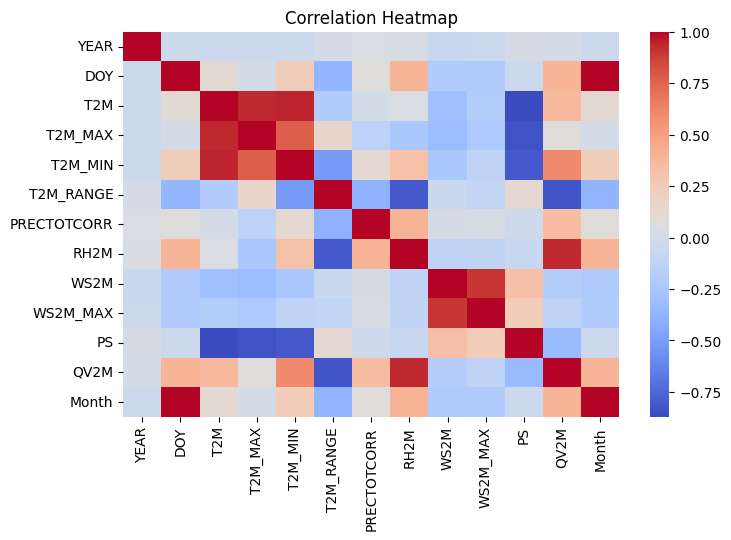

In [14]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

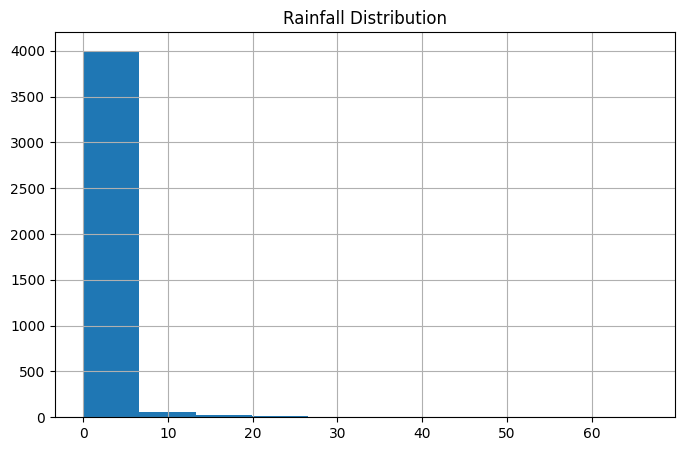

In [20]:
df["PRECTOTCORR"].hist()
plt.title("Rainfall Distribution")
plt.show()

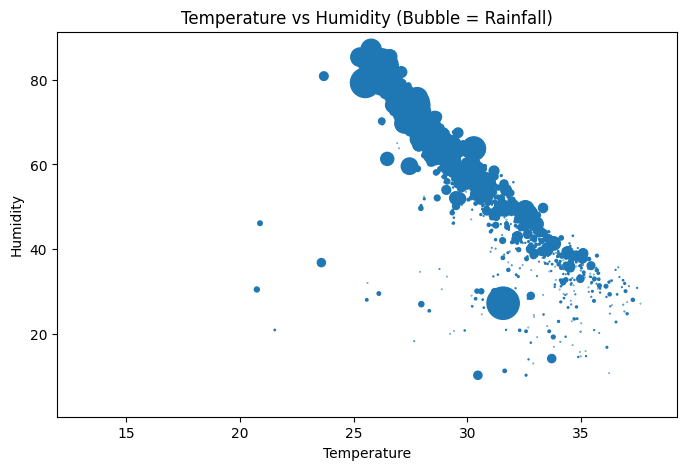

In [15]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10)
plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()